# Random Forest Trade Filter
### Meta-labeling layer on top of the EWMA crossover strategy

The EWMA crossing model decides **side** $\{-1, +1\}$.  
This notebook trains a Random Forest to decide **whether to trade at all** $\{0, 1\}$,
i.e., to **meta-label** each crossover event.

Pipeline:
1. Reproduce the crossover events and triple-barrier labels from the primary model.
2. Engineer features that are available **at the time of the event** (no look-ahead).
3. Compute **overlap-uniqueness weights** so the RF loss is not distorted by
   overlapping barrier windows (López de Prado, *AFML* §4).
4. Walk-forward train/test split with an embargo gap.
5. Evaluate with overlap-weighted F1 and plot the equity curves for  
   **All signals** vs **Filtered signals** vs **Buy & Hold**.


In [104]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics  import (classification_report, precision_score, recall_score, f1_score,
                               ConfusionMatrixDisplay)
from sklearn.utils    import check_random_state

warnings.filterwarnings("ignore")

# ── Load data ──────────────────────────────────────────────────────────────
DATA_PATH = r'G:\Mi unidad\2026\Tesis\Códigos\Data\sp500_2015_to_2025_dollar_bars.csv'

raw   = pd.read_csv(DATA_PATH)
raw['timestamp'] = pd.to_datetime(raw['timestamp'])
raw   = raw.set_index('timestamp').sort_index()
close = raw['Close'].astype(float)
high  = raw['High'].astype(float)
low   = raw['Low'].astype(float)
volume = raw['Volume'].astype(float) if 'Volume' in raw.columns else None

print(f"Loaded {len(close):,} bars  "
      f"| {close.index[0].date()} → {close.index[-1].date()}")


Loaded 2,048 bars  | 2017-01-11 → 2025-12-30


## 1 — Primary model: EWMA crossover events + triple-barrier labels
Reproduces the labeling from `Trend_Following_Strategy_v2` so this script
is self-contained.


In [116]:
# ── Hyper-parameters (mirror v2) ──────────────────────────────────────────
FAST_SPAN = 3
SLOW_SPAN = 5
BURN_IN   = SLOW_SPAN #* 3
NUM_BARS  = 63          # vertical barrier
PT_SL     = [1.0, 1.0]  # symmetric barriers
MIN_RET   = 0.01
VOL_SPAN  = 20

# ── EWMA crossover events ─────────────────────────────────────────────────
def get_crossover_events(close, fast_span=FAST_SPAN, slow_span=SLOW_SPAN,
                         burn_in=BURN_IN):
    fast = close.ewm(span=fast_span, adjust=False).mean()
    slow = close.ewm(span=slow_span, adjust=False).mean()
    fast, slow = fast.iloc[burn_in:], slow.iloc[burn_in:]
    diff = fast - slow
    bullish = (diff.shift(1) <= 0) & (diff > 0)
    bearish = (diff.shift(1) >= 0) & (diff < 0)
    df = pd.DataFrame({'fast_ewma': fast, 'slow_ewma': slow})
    df['side'] = np.where(bullish, 1, np.where(bearish, -1, 0))
    return df[df['side'] != 0].copy()

events_cross = get_crossover_events(close)
print(f"Crossover events: {len(events_cross)} "
      f"(bull={( events_cross['side']==1).sum()}, "
      f"bear={(events_cross['side']==-1).sum()})")


Crossover events: 320 (bull=160, bear=160)


In [117]:
vol_20 = close.pct_change().ewm(span=20, adjust=False).std()
print(f"mean vol_20: {vol_20.mean():.4f}  |  std vol_20: {vol_20.std():.4f}") 
print(f"max vol_20: {vol_20.max():.4f}  |  min vol_20: {vol_20.min():.4f}")

mean vol_20: 0.0100  |  std vol_20: 0.0051
max vol_20: 0.0359  |  min vol_20: 0.0025


In [118]:
def _apply_barriers(close, events, pt_sl):
    """Return DataFrame(pt, sl) — first time each barrier is touched."""
    # Prepare an output DataFrame indexed by event entry times with two
    # columns: 'pt' (profit-taking touch time) and 'sl' (stop-loss touch time).
    out = pd.DataFrame(index=events.index,
                       columns=['pt', 'sl'],
                       dtype='datetime64[ns]')
    # Iterate over labeled events; 'loc' is the event timestamp (entry).
    for loc, ev in events.iterrows():
        try:
            # Find the integer location of the event in the price index.
            lp = close.index.get_loc(loc)
        except KeyError:
            # If the event timestamp is not present in the price index, skip.
            continue
        # Determine the index position of the vertical barrier (t1).
        ep = close.index.get_indexer(
            [ev['t1'] if pd.notna(ev['t1']) else close.index[-1]],
            method='bfill')[0]
        # Start checking from the next bar after the entry.
        sp = lp + 1
        # If the entry is after the barrier, nothing to check.
        if sp > ep:
            continue
        # Extract the price path between entry+1 and the barrier (inclusive).
        path = close.iloc[sp: ep + 1]
        # Need at least two bars (entry reference + one subsequent bar) to compute returns.
        if len(path) < 2:
            continue
        # Compute returns relative to the first bar in the path, then align to the
        # signal direction by multiplying by ev['side'] (+1/-1).
        rets = (path.iloc[1:] / path.iloc[0] - 1.0) * ev['side']
        # Profit-taking: first time return >= pt threshold * target volatility.
        if pt_sl[0] > 0:
            hit = rets[rets >=  pt_sl[0] * ev['trgt']]
            if not hit.empty:
                # Record the timestamp of the first hit (earliest index in hit).
                out.loc[loc, 'pt'] = hit.index[0]
        # Stop-loss: first time return <= -sl threshold * target volatility.
        if pt_sl[1] > 0:
            hit = rets[rets <= -pt_sl[1] * ev['trgt']]
            if not hit.empty:
                out.loc[loc, 'sl'] = hit.index[0]
    # Ensure returned timestamps are proper datetimes (NaT preserved where no hit).
    out['pt'] = pd.to_datetime(out['pt'])
    out['sl'] = pd.to_datetime(out['sl'])
    return out


def get_labeled_events(close, events_cross, pt_sl, vol_span,
                       min_ret, num_bars):
    """
    Build the canonical labeled-event table.

    Returns columns: t1, trgt, side, t_hit, label
        label = +1 (PT hit)
                -1 (SL hit)
                 0 (vertical barrier / timeout)
    """
    # All event timestamps from the crossover detector
    tEvents = events_cross.index
    # Target (trgt) is the EWM standard deviation of 1-bar returns (volatility estimate).
    trgt    = 5 * close.pct_change().ewm(span=vol_span, adjust=False).std()
    # Keep only targets for times where we actually had events; drop NaNs.
    trgt    = trgt.reindex(tEvents).dropna()
    # Discard events whose volatility target is too small (filter by min_ret).
    trgt    = trgt[trgt > min_ret]

    # Vertical barrier: map each event to its barrier timestamp (num_bars ahead).
    pos = close.index.get_indexer(trgt.index, method='backfill')
    barrier_pos = np.minimum(pos + num_bars, len(close) - 1)
    t1 = pd.Series(close.index[barrier_pos], index=trgt.index)

    # Build base event table with t1 and volatility target
    ev = pd.DataFrame({'t1': t1, 'trgt': trgt})
    # Attach the EWMA side signal (+1/-1) to each event (reindex to align).
    ev['side'] = events_cross['side'].reindex(ev.index).astype(float)

    # Find first touch times for pt/sl within each event window.
    hits = _apply_barriers(close, ev, pt_sl)

    # Combine the vertical-barrier time with any pt/sl hit times so we can
    # compute the earliest time that ended the event (t_hit).
    cand = pd.concat([ev['t1'], hits['pt'], hits['sl']], axis=1)
    cand.columns = ['t1', 'pt', 'sl']
    # Stack columns to a single Series per event and take the earliest timestamp.
    ev['t_hit'] = cand.stack(dropna=True).groupby(level=0).min()

    # Determine label: +1 if PT occurred in signal direction, -1 if SL occurred
    # (opposite direction), 0 otherwise (should include vertical/timeouts).
    def _label(row):
        if pd.isna(row['t_hit']):
            return 0
        # If profit-taking timestamp exists and is the one that ended the event,
        # label according to the signal side (correct trade).
        if pd.notna(hits.loc[row.name, 'pt']) and row['t_hit'] == hits.loc[row.name, 'pt']:
            return int(row['side'])
        # If stop-loss timestamp exists and ended the event, label opposite sign.
        if pd.notna(hits.loc[row.name, 'sl']) and row['t_hit'] == hits.loc[row.name, 'sl']:
            return -int(row['side'])
        return 0

    ev['label'] = ev.apply(_label, axis=1)
    return ev


labeled = get_labeled_events(close, events_cross,
                             PT_SL, VOL_SPAN, MIN_RET, NUM_BARS)
print(f"Labeled events : {len(labeled)}")
print(labeled['label'].value_counts()
      .rename({1:'PT (+1)', -1:'SL (-1)', 0:'Vertical (0)'}))


Labeled events : 320
label
PT (+1)         211
SL (-1)          80
Vertical (0)     29
Name: count, dtype: int64


## 2 — Meta-labels  $y \in \{0, 1\}$

The RF target is:

$$y_i = \mathbf{1}[\ell_i \cdot s_i > 0]$$

where $\ell_i \in \{-1, 0, +1\}$ is the triple-barrier label and
$s_i \in \{-1, +1\}$ is the EWMA side.  
$y_i = 1$ means "the crossover signal was correct — trade it";  
$y_i = 0$ means "the primary model was wrong or inconclusive — skip it."

Vertical-barrier events ($\ell_i = 0$) are mapped to $y_i = 0$ (do not trade).


In [119]:
# y = 1  iff the primary model's side was correct (PT hit in the signal direction)
labeled['meta_label'] = (labeled['label'] * labeled['side'] > 0).astype(int)

print("Meta-label distribution:")
print(labeled['meta_label'].value_counts().rename({1:'Trade (1)', 0:'Skip (0)'}))
print(f"  Positive rate: {labeled['meta_label'].mean():.3f}")


Meta-label distribution:
meta_label
Skip (0)     169
Trade (1)    151
Name: count, dtype: int64
  Positive rate: 0.472



Example of label 1:
t1            2017-03-24 15:05:00
trgt                     0.014856
side                         -1.0
t_hit         2017-02-09 16:50:00
label                           1
meta_label                      0
Name: 2017-01-20 19:35:00, dtype: object

Example of label -1:
t1            2018-07-11 16:55:00
trgt                     0.057405
side                         -1.0
t_hit         2018-04-02 19:25:00
label                          -1
meta_label                      1
Name: 2018-03-07 18:19:00, dtype: object

Example of label 0:
t1            2018-07-09 19:00:00
trgt                     0.058453
side                          1.0
t_hit         2018-07-09 19:00:00
label                           0
meta_label                      0
Name: 2018-03-06 14:34:00, dtype: object


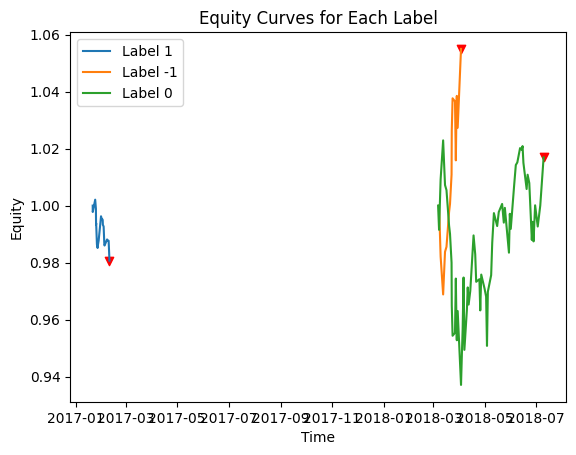

In [120]:
#Show examples of each label and plot the equity curve of a few examples
for lbl in [1, -1, 0]:
    example = labeled[labeled['label'] == lbl].iloc[4]
    print(f"\nExample of label {lbl}:\n{example}")
    # Plot equity curve for this example
    start = example.name
    end = example['t_hit'] if pd.notna(example['t_hit']) else example['t1']
    path = close.loc[start:end]

    if len(path) > 1:
        equity_curve = (1 + example['side'] * path.pct_change().fillna(0)).cumprod()
        plt.plot(equity_curve.index, equity_curve.values, label=f'Label {lbl}')
        #Show entry and exit points
        # plt.scatter(example.name, 1.0, color='green', marker='^')
        if pd.notna(example['t_hit']):
            plt.scatter(example['t_hit'], equity_curve.loc[example['t_hit']], color='red', marker='v')
    


plt.xlabel('Time')
plt.ylabel('Equity')
plt.title('Equity Curves for Each Label')
plt.legend()
plt.show()

## 3 — Feature engineering

All features are computed **strictly from information available at the event
timestamp** $t_i$, using a look-back window that ends at $t_i$ (never forward).

| Feature | Description |
|---------|-------------|
| `ret_1`, `ret_5`, `ret_20` | Log-returns over past 1, 5, 20 bars |
| `vol_20` | Realized volatility (EWM std of 1-bar returns, span=20) |
| `vol_ratio` | `vol_5 / vol_20` — vol regime indicator |
| `ewma_gap` | Normalized distance between fast and slow EWMA: $(m_f - m_s)/P$ |
| `rsi_14` | Relative Strength Index, 14 bars |
| `bb_pct` | Bollinger %B: position within $[\mu \pm 2\sigma]_{20}$ |
| `side` | EWMA signal direction $\{-1, +1\}$ (the primary model output) |


In [121]:
def build_features(close, events_cross, fast_span=FAST_SPAN,
                   slow_span=SLOW_SPAN):
    """
    Compute features at each event timestamp using only look-back information.

    All rolling/EWM computations are performed on the full price series first;
    then we simply index into the result at event timestamps — no forward bias.
    """
    log_ret = np.log(close / close.shift(1))

    # ── Returns ──────────────────────────────────────────────────────────────
    ret_1  = log_ret
    ret_5  = log_ret.rolling(5).sum()
    ret_20 = log_ret.rolling(63).sum()

    # ── Volatility ───────────────────────────────────────────────────────────
    vol_5  = log_ret.ewm(span=5,  adjust=False).std()
    vol_20 = log_ret.ewm(span=20, adjust=False).std()
    vol_ratio = (vol_5 / vol_20).replace([np.inf, -np.inf], np.nan)

    # ── EWMA gap (normalized) ─────────────────────────────────────────────────
    fast   = close.ewm(span=fast_span, adjust=False).mean()
    slow   = close.ewm(span=slow_span, adjust=False).mean()
    ewma_gap = (fast - slow) / close

    # ── RSI (14) ──────────────────────────────────────────────────────────────
    delta  = close.diff()
    gain   = delta.clip(lower=0).ewm(span=14, adjust=False).mean()
    loss   = (-delta.clip(upper=0)).ewm(span=14, adjust=False).mean()
    rs     = gain / loss.replace(0, np.nan)
    rsi_14 = 100 - 100 / (1 + rs)

    # ── Bollinger %B (20, 2σ) ─────────────────────────────────────────────────
    bb_mid   = close.rolling(50).mean()
    bb_std   = close.rolling(50).std()
    bb_upper = bb_mid + 2 * bb_std
    bb_lower = bb_mid - 2 * bb_std
    # bb_pct   = (close - bb_lower) / (bb_upper - bb_lower).replace(0, np.nan)
    bb_pct = (close - bb_mid)/(2*bb_std)

    # ── Assemble at event timestamps ──────────────────────────────────────────
    idx = events_cross.index
    X = pd.DataFrame({
        'ret_1'    : ret_1.reindex(idx),
        'ret_5'    : ret_5.reindex(idx),
        'ret_20'   : ret_20.reindex(idx),
        'vol_20'   : vol_20.reindex(idx),
        'vol_ratio': vol_ratio.reindex(idx),
        'ewma_gap' : ewma_gap.reindex(idx),
        'rsi_14'   : rsi_14.reindex(idx),
        'bb_pct'   : bb_pct.reindex(idx),
        'side'     : events_cross['side'].astype(float),
    }, index=idx)

    return X


X_all = build_features(close, events_cross)

# Align to labeled events and drop rows with NaN features
X_all = X_all.reindex(labeled.index)
mask  = X_all.notna().all(axis=1)
X_all = X_all[mask]
y_all = labeled.loc[mask, 'meta_label']

print(f"Feature matrix : {X_all.shape}")
print(f"NaN rows dropped: {(~mask).sum()}")
print(X_all.describe().round(4))


Feature matrix : (308, 9)
NaN rows dropped: 12
          ret_1     ret_5    ret_20    vol_20  vol_ratio  ewma_gap    rsi_14  \
count  308.0000  308.0000  308.0000  308.0000   308.0000  308.0000  308.0000   
mean     0.0006   -0.0001    0.0337    0.0106     1.0823    0.0001   51.8734   
std      0.0157    0.0128    0.0729    0.0050     0.2095    0.0017    8.2834   
min     -0.0563   -0.0428   -0.2996    0.0030     0.5160   -0.0059   31.0364   
25%     -0.0108   -0.0067    0.0077    0.0071     0.9475   -0.0009   45.9989   
50%      0.0011   -0.0010    0.0414    0.0099     1.0804   -0.0000   52.1050   
75%      0.0118    0.0065    0.0744    0.0127     1.2254    0.0009   57.5269   
max      0.0634    0.0538    0.2795    0.0359     1.5248    0.0067   71.1101   

         bb_pct      side  
count  308.0000  308.0000  
mean     0.2257    0.0000  
std      0.4784    1.0016  
min     -1.0374   -1.0000  
25%     -0.1461   -1.0000  
50%      0.3660    0.0000  
75%      0.5955    1.0000  
max     

## 4 — Overlap uniqueness weights

Overlapping barrier windows violate the i.i.d. assumption that underpins
most learning algorithms.  Following López de Prado (*AFML* §4.3) we weight
each sample by the fraction of its barrier window $[t_i, t_i^{\text{hit}}]$
that is not covered by any other active event:

$$w_i = \frac{1}{|\mathcal{W}_i|} \sum_{t \in [t_i, t_i^{\text{hit}}]} \frac{1}{c_t}$$

where $c_t = \sum_j \mathbf{1}[t_j \le t \le t_j^{\text{hit}}]$ is the
concurrent-event count at bar $t$ and $\mathcal{W}_i$ is the number of
bars in the window.  
We use the bar-level approximation below (no intra-bar granularity needed).


In [122]:
def compute_sample_weights(labeled: pd.DataFrame,
                           close_index: pd.Index) -> pd.Series:
    """
    Compute average-uniqueness sample weights for each labeled event.

    Parameters
    ----------
    labeled : DataFrame with columns t_hit (and index = event entry time)
    close_index : full price DatetimeIndex

    Returns
    -------
    pd.Series of weights in (0, 1], indexed like labeled.
    """
    ev = labeled[['t_hit']].dropna(subset=['t_hit']).copy()
    ev['t_hit'] = pd.to_datetime(ev['t_hit'])

    # For each bar in the price index, count how many events are active.
    n_bars = len(close_index)
    concurrent = np.zeros(n_bars, dtype=np.float32)

    entry_pos = close_index.get_indexer(ev.index,    method='bfill')
    exit_pos  = close_index.get_indexer(ev['t_hit'], method='bfill')

    for ep, xp in zip(entry_pos, exit_pos):
        if ep == -1:
            continue
        xp = min(xp if xp != -1 else n_bars - 1, n_bars - 1)
        concurrent[ep: xp + 1] += 1.0

    # Average uniqueness per event = mean of 1/c_t over its window.
    weights = []
    for (ts, row), ep, xp in zip(ev.iterrows(), entry_pos, exit_pos):
        if ep == -1:
            weights.append(1.0)
            continue
        xp = min(xp if xp != -1 else n_bars - 1, n_bars - 1)
        c  = concurrent[ep: xp + 1]
        c  = np.where(c > 0, c, 1.0)
        weights.append(float(np.mean(1.0 / c)))

    return pd.Series(weights, index=ev.index, name='weight')


# Align weights to the filtered feature matrix
weights_all = compute_sample_weights(labeled, close.index)
weights_all = weights_all.reindex(X_all.index).fillna(1.0)

print(f"Sample weights — mean: {weights_all.mean():.4f}  "
      f"| min: {weights_all.min():.4f}  "
      f"| max: {weights_all.max():.4f}")


Sample weights — mean: 0.2395  | min: 0.0796  | max: 1.0000


## 5 — Walk-forward evaluation with embargo

The data are split 70 / 30 (train / test) **in chronological order**.  
An embargo of `EMBARGO_BARS` is removed from the boundary to prevent
information leakage through overlapping barrier windows.

No hyper-parameter search is performed here — the RF is intentionally
kept simple (moderate depth, balanced class weights) to resist overfitting
on small event samples.


In [123]:
TRAIN_FRAC    = 0.70
EMBARGO_BARS  = 0 #NUM_BARS   # same width as the vertical barrier
RANDOM_STATE  = 42

# ─── Filter to SELL signals only for training ─────────────────────────────────
# side == -1 indicates sell/short signals
sell_mask = X_all['side'] == -1
X_sells = X_all[sell_mask].drop(columns=['side'])
y_sells = y_all[sell_mask]
w_sells = weights_all[sell_mask]

print(f"Total events: {len(X_all)} | Sell events: {len(X_sells)} | Buy events: {(X_all['side'] == 1).sum()}")
print(f"Sell positive rate (profitable sells): {y_sells.mean():.3f}")

n_events = len(X_sells)
n_train  = int(n_events * TRAIN_FRAC)

# Identify the last training event's t_hit to define the embargo boundary.
train_idx = X_sells.index[:n_train]
last_t1   = labeled.loc[train_idx, 't_hit'].max()

# Embargo: drop events whose entry falls within EMBARGO_BARS of last_t1.
last_bar_pos = close.index.get_indexer([last_t1], method='bfill')[0]
embargo_end  = close.index[min(last_bar_pos + EMBARGO_BARS, len(close) - 1)]

test_idx = X_sells.index[X_sells.index > embargo_end]

X_train, y_train, w_train = (X_sells.loc[train_idx],
                              y_sells.loc[train_idx],
                              w_sells.loc[train_idx])
X_test,  y_test,  w_test  = (X_sells.loc[test_idx],
                              y_sells.loc[test_idx],
                              w_sells.loc[test_idx])

print(f"\nTrain sell events : {len(X_train)}  ({train_idx[0].date()} → {train_idx[-1].date()})")
print(f"Embargo ends      : {embargo_end.date()}")
print(f"Test sell events  : {len(X_test)}  ({test_idx[0].date()} → {test_idx[-1].date()})")
print(f"Train profitable rate: {y_train.mean():.3f}")
print(f"Test profitable rate : {y_test.mean():.3f}")

# ─── Random Forest (trained only on sell signals) ───────────────────────────
rf = RandomForestClassifier(
    n_estimators     = 1000,
    max_depth        = 2,        # shallow → low variance
    min_weight_fraction_leaf= 0.05,        # floor on leaf size given small event counts
    max_features     = 'sqrt',
    class_weight     = 'balanced_subsample',
    n_jobs           = -1,
    random_state     = RANDOM_STATE,
)

rf.fit(X_train, y_train, sample_weight=w_train)
print("\nRandom Forest trained on sell signals only.")

Total events: 308 | Sell events: 154 | Buy events: 154
Sell positive rate (profitable sells): 0.279

Train sell events : 107  (2017-03-14 → 2023-05-12)
Embargo ends      : 2023-06-13
Test sell events  : 46  (2023-06-21 → 2025-12-12)
Train profitable rate: 0.262
Test profitable rate : 0.326

Random Forest trained on sell signals only.


In [124]:
# Calculate the number of parameters in the Random Forest

n_trees = rf.n_estimators
n_features = rf.n_features_in_
max_depth = rf.max_depth

# Estimate nodes per tree (approximate for a balanced tree)
# Maximum nodes in a tree of depth d: 2^(d+1) - 1
max_nodes_per_tree = 2 ** (max_depth + 1) - 1

# Total parameters: each node has a split threshold + feature index
# Rough estimate: nodes * (1 feature index + 1 threshold) per node
params_per_tree = max_nodes_per_tree * 2

total_params_estimate = n_trees * params_per_tree

print(f"Random Forest Model Complexity")
print(f"=" * 50)
print(f"Number of trees: {n_trees}")
print(f"Number of features: {n_features}")
print(f"Max depth per tree: {max_depth}")
print(f"Max nodes per tree: {max_nodes_per_tree}")
print(f"Parameters per tree (estimate): {params_per_tree}")
print(f"Total parameters (estimate): {total_params_estimate:,}")
print(f"\nActual leaf count (trained trees):")

# Count actual nodes/leaves in trained trees
total_actual_leaves = sum(tree.tree_.node_count for tree in rf.estimators_)
print(f"Total nodes across all trees: {total_actual_leaves:,}")
print(f"Average nodes per tree: {total_actual_leaves / n_trees:.0f}")

Random Forest Model Complexity
Number of trees: 1000
Number of features: 8
Max depth per tree: 2
Max nodes per tree: 7
Parameters per tree (estimate): 14
Total parameters (estimate): 14,000

Actual leaf count (trained trees):
Total nodes across all trees: 6,120
Average nodes per tree: 6


## 6 — Evaluation


Meta-label classifier — weighted precision / recall / F1 (SELL-ONLY)
                       Precision  Recall     F1
Model                                          
RF train (sells only)     0.5238  0.9726 0.6809
RF test (sells only)      0.4777  0.9588 0.6376
Primary train             0.3578  1.0000 0.5270
Primary test              0.3273  1.0000 0.4932

Comparison on test set (RF - primary)
  Precision delta: +0.1504
  Recall delta   : -0.0412
  F1 delta       : +0.1445

── Test set report (unweighted) ──
              precision    recall  f1-score   support

    Skip (0)       0.93      0.42      0.58        31
   Trade (1)       0.44      0.93      0.60        15

    accuracy                           0.59        46
   macro avg       0.68      0.68      0.59        46
weighted avg       0.77      0.59      0.58        46



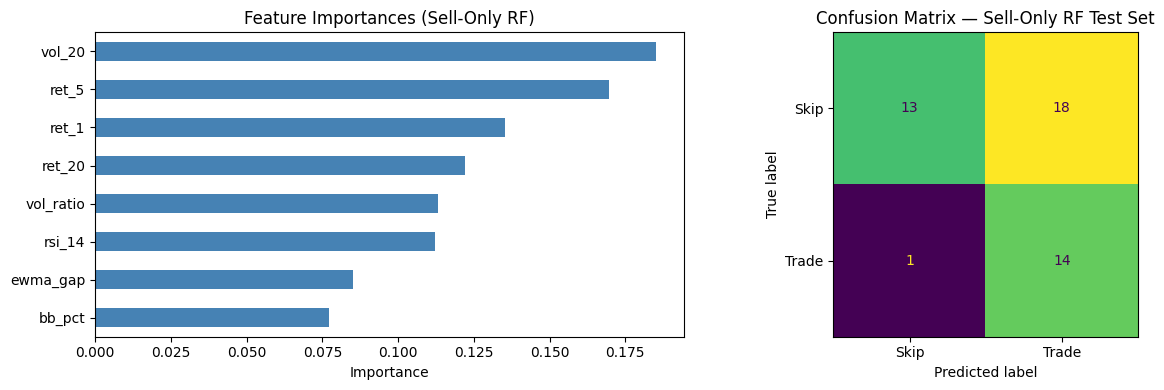

In [125]:
y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)

# Primary model baseline: always take the trade (predict class 1 for every event)
y_pred_train_primary = np.ones_like(y_train, dtype=int)
y_pred_test_primary  = np.ones_like(y_test, dtype=int)

from sklearn.metrics import precision_score, recall_score

def weighted_metrics(y_true, y_pred, weights):
    return {
        'Precision': precision_score(y_true, y_pred, sample_weight=weights, zero_division=0),
        'Recall': recall_score(y_true, y_pred, sample_weight=weights, zero_division=0),
        'F1': f1_score(y_true, y_pred, sample_weight=weights, zero_division=0),
    }

rf_train_metrics = weighted_metrics(y_train, y_pred_train, w_train)
rf_test_metrics = weighted_metrics(y_test, y_pred_test, w_test)
primary_train_metrics = weighted_metrics(y_train, y_pred_train_primary, w_train)
primary_test_metrics = weighted_metrics(y_test, y_pred_test_primary, w_test)

metrics_table = pd.DataFrame([
    {'Model': 'RF train (sells only)', **rf_train_metrics},
    {'Model': 'RF test (sells only)', **rf_test_metrics},
    {'Model': 'Primary train', **primary_train_metrics},
    {'Model': 'Primary test', **primary_test_metrics},
]).set_index('Model')

print("=" * 78)
print("Meta-label classifier — weighted precision / recall / F1 (SELL-ONLY)")
print("=" * 78)
print(metrics_table.to_string(float_format=lambda x: f'{x:.4f}'))
print()
print("Comparison on test set (RF - primary)")
print(f"  Precision delta: {rf_test_metrics['Precision'] - primary_test_metrics['Precision']:+.4f}")
print(f"  Recall delta   : {rf_test_metrics['Recall'] - primary_test_metrics['Recall']:+.4f}")
print(f"  F1 delta       : {rf_test_metrics['F1'] - primary_test_metrics['F1']:+.4f}")
print()
print("── Test set report (unweighted) ──")
print(classification_report(y_test, y_pred_test,
                             target_names=['Skip (0)', 'Trade (1)'],
                             zero_division=0))

# ── Feature importance ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Feature importances only for the trained features (excluding 'side' which was dropped)
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importances (Sell-Only RF)')
axes[0].set_xlabel('Importance')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=['Skip', 'Trade'],
    ax=axes[1], colorbar=False
)
axes[1].set_title('Confusion Matrix — Sell-Only RF Test Set')

plt.tight_layout()
plt.show()

## 7 — Backtest: All signals vs Filtered signals vs Buy & Hold

The RF filter is applied **only on the test period**.  
A filtered position is entered only when `rf.predict == 1`.  
The side (long/flat) is still determined by the EWMA crossing.

**Note:** No transaction costs are included.  Their addition is
straightforward (subtract a round-trip cost from each entry bar's return).



BACKTEST PERIOD: 2023-06-21 to 2025-12-30
                              Total Return  Max Drawdown  Bar Mean Return  Bar Volatility  Trades  Win Rate  Avg Trade Return  Median Trade Return  Profit Factor  Exposure
Primary model (all signals)         0.2529       -0.1203           0.0004          0.0063      46    0.4783            0.0053              -0.0015         1.8346    0.6401
All buys + RF-filtered sells        0.4559       -0.1142           0.0006          0.0068      32    0.5625            0.0123               0.0063         3.1310    0.6982
Buy & Hold                          0.5805       -0.1906           0.0008          0.0094       1    1.0000            0.5805               0.5805            NaN    1.0000

--------------------------------------------------------------------------------
Comparison: All buys + RF-filtered sells vs primary (all signals):
  Return delta : +20.30%
  Trade delta  : -14

Comparison: All signals vs Buy & Hold:
  Return delta : -32.77%
  Trade d

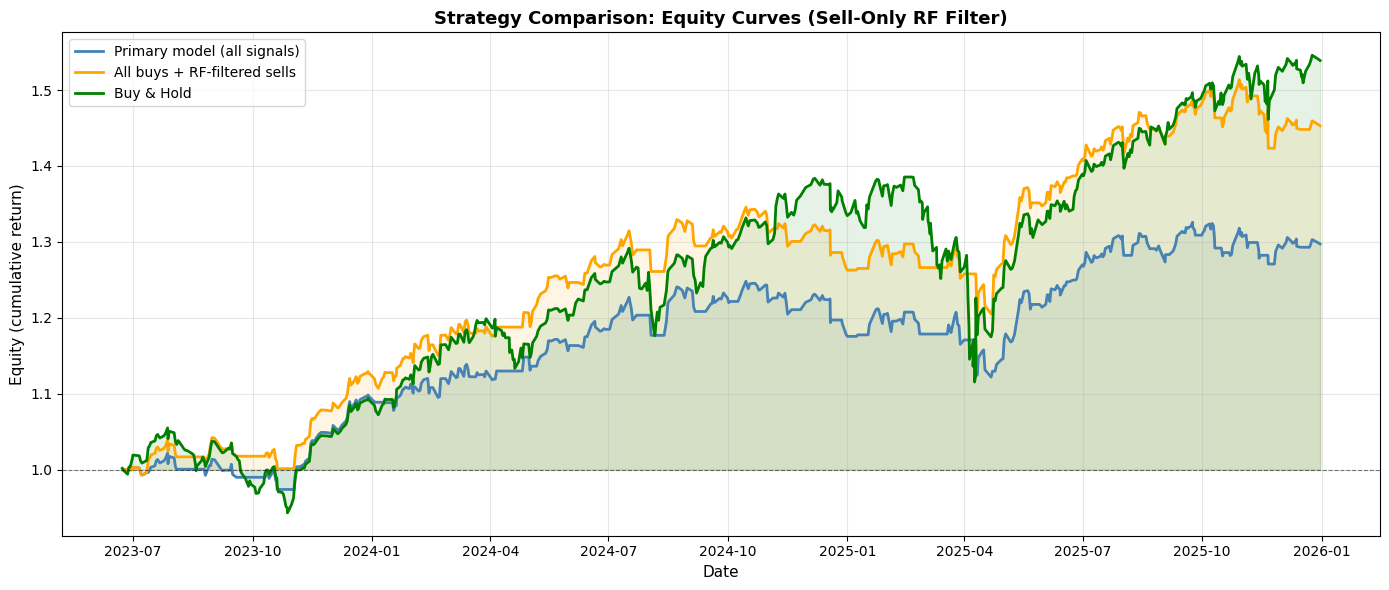

In [126]:
SLIPPAGE = 0#0.001  # 0.1% per trade (entry + exit)

# ─── Helper: build a position series from an event signal series ───────────
def build_position(close_idx, signal_events: pd.Series) -> pd.Series:
    """
    Forward-fill a position series from event signals.

    signal_events : pd.Series indexed by event timestamps with values
                    +1 (long), -1 (exit to flat).
    Returns a bar-level position series (0 or 1), shifted 1 bar to avoid
    look-ahead.
    """
    sig = signal_events.reindex(close_idx).fillna(0)
    # Map: +1 -> 1 (enter long), -1 -> 0 (exit), 0 -> NaN (carry forward)
    marker = pd.Series(np.nan, index=close_idx)
    marker[sig ==  1] = 1.0
    marker[sig == -1] = 0.0
    pos = marker.ffill().fillna(0).astype(int)
    return pos.shift(1).fillna(0).astype(int)  # execute next bar


def summarize_strategy(name: str, pos: pd.Series, bar_returns: pd.Series) -> pd.Series:
    """Summarize a bar-level strategy and its trade distribution."""
    turnover = pos.diff().abs().fillna(pos.iloc[0]).astype(float)
    strat_bar_ret = pos * bar_returns - SLIPPAGE * turnover
    equity = (1 + strat_bar_ret).cumprod()
    drawdown = equity / equity.cummax() - 1.0
    trade_group = (pos.ne(pos.shift())).cumsum()
    trade_returns = []
    for _, grp in strat_bar_ret.groupby(trade_group):
        if pos.loc[grp.index[0]] == 1:
            trade_returns.append((1 + grp).prod() - 1)
    trade_returns = pd.Series(trade_returns, dtype=float)
    n_trades = int(trade_returns.shape[0])
    win_rate = float((trade_returns > 0).mean()) if n_trades else np.nan
    avg_trade_return = float(trade_returns.mean()) if n_trades else np.nan
    median_trade_return = float(trade_returns.median()) if n_trades else np.nan
    profit_factor = np.nan
    if n_trades:
        gross_profit = trade_returns[trade_returns > 0].sum()
        gross_loss = -trade_returns[trade_returns < 0].sum()
        if gross_loss > 0:
            profit_factor = float(gross_profit / gross_loss)
    return pd.Series({
        'Total Return': float(equity.iloc[-1] - 1.0),
        'Max Drawdown': float(drawdown.min()),
        'Bar Mean Return': float(strat_bar_ret.mean()),
        'Bar Volatility': float(strat_bar_ret.std(ddof=0)),
        'Trades': n_trades,
        'Win Rate': win_rate,
        'Avg Trade Return': avg_trade_return,
        'Median Trade Return': median_trade_return,
        'Profit Factor': profit_factor,
        'Exposure': float(pos.mean()),
        'Trade Returns': trade_returns,
    }, name=name)


# ─── Test-period price returns ─────────────────────────────────────────────
test_start = test_idx[0]
close_test = close[close.index >= test_start]
ret_test   = close_test.pct_change().fillna(0)
log_ret_test = np.log(1 + ret_test)

# ─── 1. Primary model: take every crossover signal in the test period ─────────
cross_test = events_cross.loc[events_cross.index >= test_start, 'side']
pos_all    = build_position(close_test.index, cross_test)

# ─── 2. Asymmetric filtered strategy: ALL buys + RF-filtered sells ──────────────
# Take ALL buy signals (+1), but only take sell signals (-1) when RF predicts profitable (=1).
rf_decisions = pd.Series(y_pred_test, index=test_idx)
asym_sig = cross_test.copy()

for ts in test_idx:
    if ts in asym_sig.index:
        if asym_sig.loc[ts] == -1:  # This is a sell signal
            if rf_decisions.loc[ts] == 0:  # RF predicts unprofitable
                asym_sig[ts] = 0  # Skip this sell (no signal)
        # Buy signals (+1) are always kept unchanged

pos_filt = build_position(close_test.index, asym_sig)

# ─── 3. Buy & Hold benchmark ──────────────────────────────────────────────
pos_bh   = pd.Series(1, index=close_test.index, dtype=int)

# ─── Compute comprehensive statistics ────────────────────────────────────────────
primary_stats  = summarize_strategy('Primary model (all signals)', pos_all,  ret_test)
filtered_stats = summarize_strategy('All buys + RF-filtered sells', pos_filt, ret_test)
bh_stats       = summarize_strategy('Buy & Hold', pos_bh, ret_test)

stats = pd.DataFrame([primary_stats, filtered_stats, bh_stats])
stats_to_show = stats.drop(columns=['Trade Returns'])

ret_all  = primary_stats['Total Return']
ret_filt = filtered_stats['Total Return']
ret_bh   = bh_stats['Total Return']

n_all  = int(primary_stats['Trades'])
n_filt = int(filtered_stats['Trades'])

print('\n' + '='*80)
print(f'BACKTEST PERIOD: {close_test.index[0].date()} to {close_test.index[-1].date()}')
print('='*80)
print(stats_to_show.to_string(float_format=lambda x: f'{x:,.4f}'))

print('\n' + '-'*80)
print('Comparison: All buys + RF-filtered sells vs primary (all signals):')
print(f'  Return delta : {(ret_filt - ret_all):+.2%}')
print(f'  Trade delta  : {(n_filt - n_all):+d}')

print('\nComparison: All signals vs Buy & Hold:')
print(f'  Return delta : {(ret_all - ret_bh):+.2%}')
print(f'  Trade delta  : {(n_all - 1):+d}')

# ─── Single equity curve comparing all three strategies ─────────────────────────
eq_all  = (1 + (pos_all.shift(1) * log_ret_test)).cumprod()
eq_filt = (1 + (pos_filt.shift(1) * log_ret_test)).cumprod()
eq_bh   = (1 + (pos_bh.shift(1) * log_ret_test)).cumprod()

fig, ax = plt.subplots(figsize=(14, 6))

# Plot all three strategies on the same chart
ax.plot(eq_all.index, eq_all.values, label='Primary model (all signals)', linewidth=2, color='steelblue')
ax.plot(eq_filt.index, eq_filt.values, label='All buys + RF-filtered sells', linewidth=2, color='orange')
ax.plot(eq_bh.index, eq_bh.values, label='Buy & Hold', linewidth=2, color='green')

ax.fill_between(eq_all.index, 1, eq_all.values, alpha=0.1, color='steelblue')
ax.fill_between(eq_filt.index, 1, eq_filt.values, alpha=0.1, color='orange')
ax.fill_between(eq_bh.index, 1, eq_bh.values, alpha=0.1, color='green')

ax.set_title('Strategy Comparison: Equity Curves (Sell-Only RF Filter)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Equity (cumulative return)', fontsize=11)
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)

# Add horizontal line at 1.0 (no return)
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

## Red-team critique

| Risk | Description |
|------|-------------|
| **Small event count** | EWMA crossovers are infrequent; the RF trains on O(100) events. With ≤ 9 features and `max_depth=4`, the model capacity is intentionally limited but overfitting remains a concern. A permutation test on the meta-label F1 is recommended. |
| **Feature–label correlation** | `side` (the EWMA direction) is both a feature and embedded in the meta-label definition. It is included deliberately — the RF should learn *when* the side is reliable — but it inflates apparent feature importance. |
| **Non-stationarity** | Features such as `bb_pct` and `rsi_14` are mean-reverting by construction; their predictive relationship with the meta-label may shift across regimes. |
| **No transaction costs** | Each filtered-in signal still incurs a round-trip cost; the filtered curve's advantage narrows under realistic cost assumptions. |
| **Single train/test split** | A single 70/30 split does not characterize estimation variance. A proper combinatorial purged cross-validation (CPCV, *AFML* §12) would be needed for thesis-grade inference. |
